In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Semua library berhasil dipanggil!")

Semua library berhasil dipanggil!


In [2]:
df = pd.read_csv(r'E:\project\Data Analisis\latihan1\Superstore_Data.csv', encoding='ISO-8859-1')
# tambahan parameter: encoding='ISO-8859-1' karena file csv disimpan tidak sesuai standar='UTF-8'

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# melihat nama-nam kolom dan deteksi missing value
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [5]:
# merubah type data Order Date & Ship Date dari str menjadi datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Kita cek kembali tipenya untuk memastikan sudah berubah
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

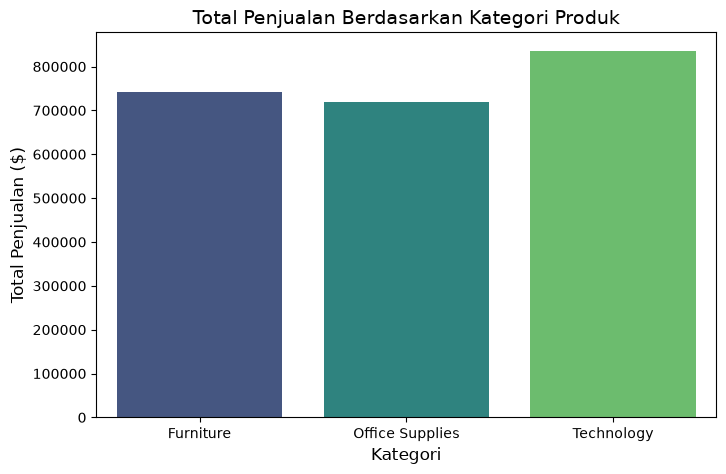

In [6]:
# Membuat grafik visualisasi
# Mengelompokkan total penjualan berdasarkan kategori
sales_by_category = df.groupby('Category')['Sales'].sum().reset_index()

# Membuat grafik batang menggunakan Seaborn
plt.figure(figsize=(8, 5))
# Tambahkan hue='Category' dan legend=False, karena jika hue saja akan otomatis muncul kotak legenda
#legenda tidak dip[erlukan karena sudah jelas keterangan kategorinya dibawah
sns.barplot(x='Category', y='Sales', data=sales_by_category, hue='Category', palette='viridis', legend=False) 

# Memberikan judul dan label pada grafik
plt.title('Total Penjualan Berdasarkan Kategori Produk', fontsize=14)
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Total Penjualan ($)', fontsize=12)

# Menampilkan grafik
plt.show()


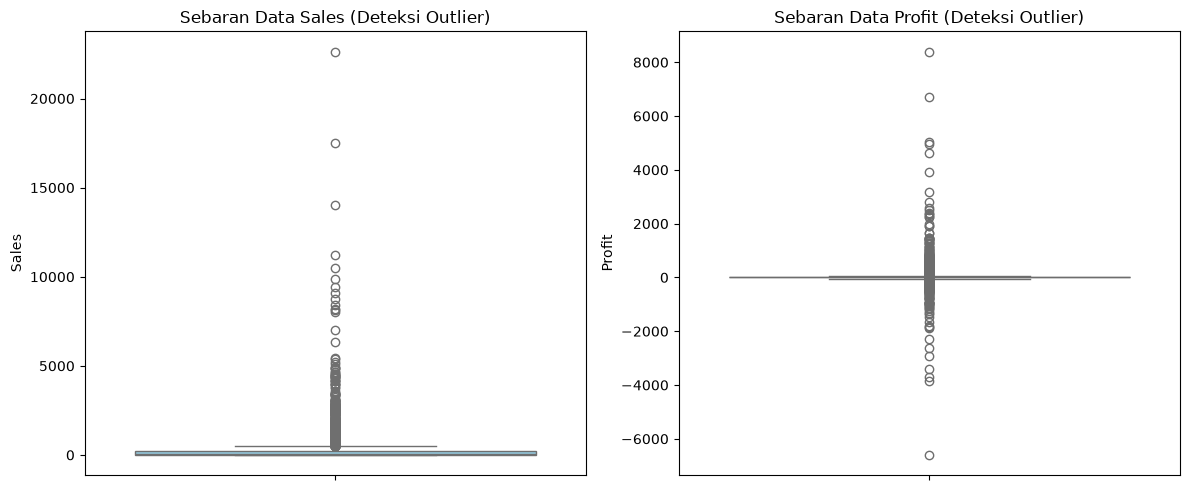

In [7]:
# Analisa Outlier dengan visualisasi menggunakan boxplot
# Membuat subplots untuk membandingkan Sales dan Profit
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot untuk Sales
sns.boxplot(y=df['Sales'], ax=axes[0], color='skyblue')
axes[0].set_title('Sebaran Data Sales (Deteksi Outlier)')

# Boxplot untuk Profit
sns.boxplot(y=df['Profit'], ax=axes[1], color='salmon')
axes[1].set_title('Sebaran Data Profit (Deteksi Outlier)')

plt.tight_layout()

plt.show()


In [8]:
# Analisa penyumbang kerugian atau keuntungan terkecil
# Memfilter data dengan profit paling minimum (paling rugi) diambil 3 data terkecil
df.sort_values(by='Profit').head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7772,7773,CA-2016-108196,2016-11-25,2016-12-02,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,43130,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
683,684,US-2017-168116,2017-11-04,2017-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,27217,South,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
9774,9775,CA-2014-169019,2014-07-26,2014-07-30,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,78207,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928


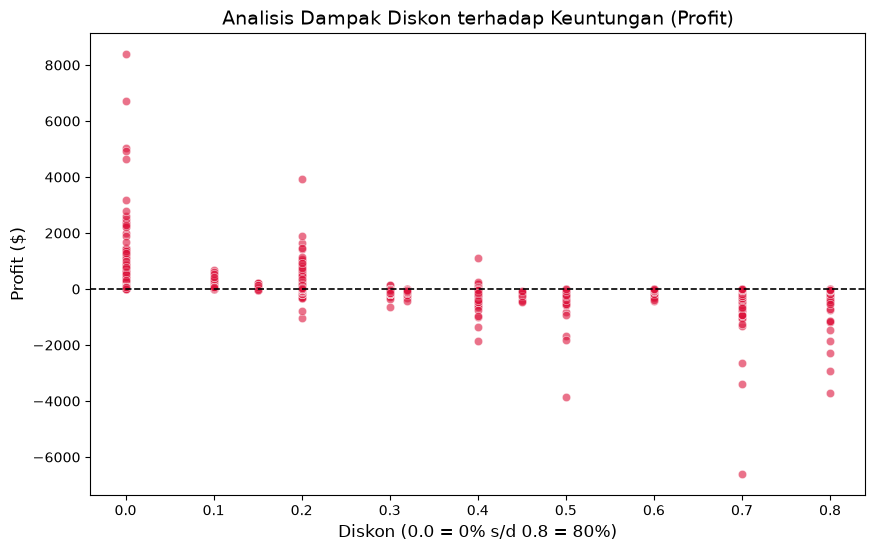

In [9]:
# Visualisasi dampak diskon terhadap profit
plt.figure(figsize=(10, 6))
# Membuat scatter plot untuk melihat pola hubungan diskon dan profit
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6, color='crimson')

# Menambahkan garis horizontal di angka 0 sebagai batas untung/rugi
plt.axhline(0, color='black', linestyle='--', linewidth=1.2)

plt.title('Analisis Dampak Diskon terhadap Keuntungan (Profit)', fontsize=14)
plt.xlabel('Diskon (0.0 = 0% s/d 0.8 = 80%)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)

plt.show()


In [10]:
# 1. Filter hanya transaksi yang mengalami kerugian (Profit < 0)
data_rugi = df[df['Profit'] < 0]

# 2. Kelompokkan berdasarkan Region dan hitung total kerugian serta rata-rata diskonnya
loss_by_region = data_rugi.groupby('Region').agg(
    Total_Kerugian=('Profit', 'sum'),
    Rata_Rata_Diskon=('Discount', 'mean'),
    Jumlah_Transaksi_Rugi=('Profit', 'count')
).reset_index()

# 3. Urutkan dari kerugian terbesar
loss_by_region = loss_by_region.sort_values(by='Total_Kerugian', ascending=True)

loss_by_region


,Region,Total_Kerugian,Rata_Rata_Diskon,Jumlah_Transaksi_Rugi
0,Central,-56314.8850,0.549447,741
1,East,-49590.6075,0.446835,553
2,South,-27504.8323,0.491699,259
3,West,-22720.9609,0.371541,318
